In [1]:
"""
Main script to run the recalibration experiments
"""
# Author: Alessandro Brusaferri
# License: Apache-2.0 license

import os
import pandas as pd
import numpy as np
os.environ["TF_USE_LEGACY_KERAS"]="1"
from tools.PrTSF_Recalib_tools import PrTsfRecalibEngine, load_data_model_configs
from tools.prediction_quantiles_tools import plot_quantiles



In [2]:

def compute_pinball_scores(y_true, pred_quantiles, quantiles_levels):
    """
    Utility function to compute the pinball score on the test results
    return: pinball scores computed for each quantile level and each step in the pred horizon
    """
    score = []
    for i, q in enumerate(quantiles_levels):
        error = np.subtract(y_true, pred_quantiles[:, :, i])
        loss_q = np.maximum(q * error, (q - 1) * error)
        score.append(np.expand_dims(loss_q,-1))
    score = np.mean(np.concatenate(score, axis=-1), axis=0)
    return score


# compute the winkler score
def compute_winkler_scores(y_true, pred_quantiles, quantiles_levels):
    """
    Utility function to compute the winkler score on the test results
    return: winkler scores computed for each quantile level and each step in the pred horizon
    """
    score = []
    # loop over only half the quantiles
    # the other half is symmetric, winkler is only applied to quantiles above (or below) the median
    for i, tau in enumerate(quantiles_levels[:len(quantiles_levels)//2]):
        # get the upper and lower quantiles
        L_tau = pred_quantiles[:, :, i]
        U_tau = pred_quantiles[:, :, -i-1]
        # compute the quantile width
        delta_tau = np.subtract(U_tau, L_tau)
        # compute the errors
        error_L = np.subtract(L_tau, y_true)
        error_U = np.subtract(y_true, U_tau)
        # compute the winkler score
        # use tau, not 1-tau, as the quantiles are symmetric
        loss_q = delta_tau + 2 / tau * (
            np.maximum(error_L, np.zeros(error_L.shape))
            + np.maximum(error_U, np.zeros(error_U.shape))
        )
        score.append(np.expand_dims(loss_q,-1))
    score = np.mean(np.concatenate(score, axis=-1), axis=0)

    return score


In [3]:
# Set PEPF task to execute
PF_task_name = 'EM_price'
# Set Model setup to execute
exper_setup = 'JSU-DNN'


# Set run configs

# fix the seed for reproducibility
np.random.seed(42)

run_id = 'recalib_opt_grid_1_1'
# run_id = 'recalib_opt_random_1_2'
# Load hyperparams from file (select: load_tuned or optuna_tuner)
hyper_mode = 'load_tuned'
# Plot train history flag
plot_train_history=True
plot_weights=True
# Apply sinh transformation to the target variable
apply_arcsinh_transf = False

In [4]:
# Load experiments configuration from json file
configs=load_data_model_configs(task_name=PF_task_name, exper_setup=exper_setup, run_id=run_id)

# Load dataset
# ***: This lets us change the dataset before passing it directly to the recalibration engine
# ***: e.g. preprocessing, feature selection, etc.
dir_path = os.getcwd()
ds = pd.read_csv(os.path.join(dir_path, 'data', 'datasets', configs['data_config'].dataset_name))
ds.set_index(ds.columns[0], inplace=True)

if apply_arcsinh_transf:
    ds['TARG__'+PF_task_name] = np.arcsinh(ds['TARG__'+PF_task_name])

-----------------------------------------
Loading tuned hyperparams
-----------------------------------------
------------------------------------------------------------------------------
Starting recalibration of config: JSU
------------------------------------------------------------------------------

Recalibrating test sample: 1/1



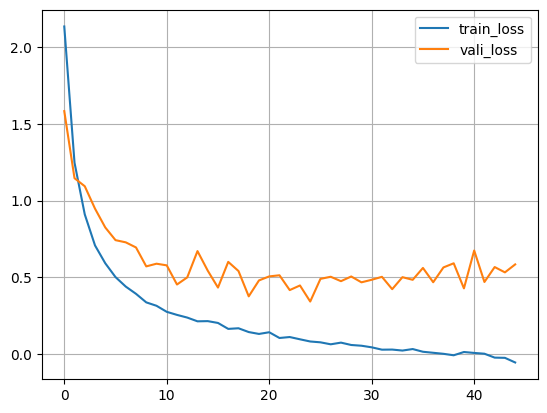

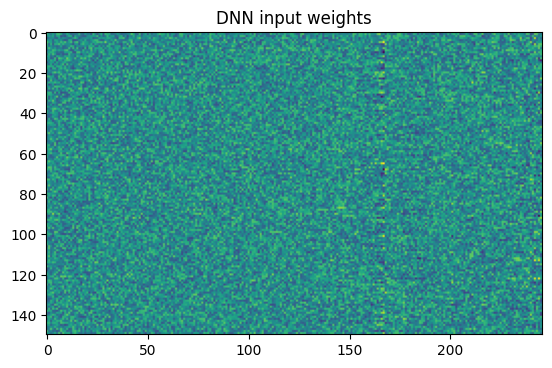

In [5]:
# Instantiate recalibratione engine
PrTSF_eng = PrTsfRecalibEngine(dataset=ds,
                               data_configs=configs['data_config'],
                               model_configs=configs['model_config'])

# Get model hyperparameters (previously saved or by tuning)
model_hyperparams = PrTSF_eng.get_model_hyperparams(method=hyper_mode, optuna_m=configs['model_config']['optuna_m'])

# Exec recalib loop over the test_set samples, using the tuned hyperparams
test_predictions = PrTSF_eng.run_recalibration(model_hyperparams=model_hyperparams,
                                               plot_history=plot_train_history,
                                               plot_weights=plot_weights)

# apply inverse sinh transformation to all the predictions
if apply_arcsinh_transf:
    test_predictions = np.sinh(test_predictions)


In [6]:
# Compute pinball score
quantiles_levels = PrTSF_eng.model_configs['target_quantiles']
pred_steps = configs['model_config']['pred_horiz']

pinball_scores = compute_pinball_scores(y_true=test_predictions[PF_task_name].to_numpy().reshape(-1,pred_steps),
                                        pred_quantiles=test_predictions.loc[:,test_predictions.columns != PF_task_name].
                                        to_numpy().reshape(-1, pred_steps, len(quantiles_levels)),
                                        quantiles_levels=quantiles_levels)

# print the Pinball score as a table
pinbal_df = pd.DataFrame(pinball_scores, columns=[f'q_{q}' for q in quantiles_levels], index=[f'Hour {i+1}' for i in range(pred_steps)])
print('--- Pinball Scores ---')
print(pinbal_df)

# save pinball scores to file
pinbal_df.to_csv(os.path.join(dir_path, 'experiments', 'tasks', PF_task_name, exper_setup, run_id, 'pinball_scores.csv'))

--- Pinball Scores ---
          q_0.005    q_0.01   q_0.015    q_0.02   q_0.025    q_0.03   q_0.035  \
Hour 1   0.059602  0.106853  0.148210  0.187081  0.222097  0.252293  0.282937   
Hour 2   0.051883  0.089681  0.120240  0.150212  0.176885  0.199619  0.223644   
Hour 3   0.056237  0.098845  0.137910  0.171727  0.205097  0.236702  0.264259   
Hour 4   0.057565  0.102487  0.145681  0.181246  0.211311  0.242144  0.272294   
Hour 5   0.067970  0.122247  0.173160  0.222047  0.262934  0.303275  0.340990   
Hour 6   0.087136  0.153296  0.210991  0.258684  0.306505  0.351909  0.396058   
Hour 7   0.071773  0.129976  0.180732  0.229803  0.276741  0.319049  0.363175   
Hour 8   0.080862  0.150775  0.214401  0.267989  0.322042  0.373141  0.421346   
Hour 9   0.075947  0.138401  0.194812  0.248275  0.298879  0.343578  0.388537   
Hour 10  0.089045  0.158206  0.222833  0.278434  0.325543  0.373120  0.411843   
Hour 11  0.059948  0.102082  0.141563  0.174089  0.205458  0.233164  0.259288   
Hour 

In [7]:
# Compute winkler score
winkler_scores = compute_winkler_scores(y_true=test_predictions[PF_task_name].to_numpy().reshape(-1,pred_steps),
                                        pred_quantiles=test_predictions.loc[:,test_predictions.columns != PF_task_name].
                                        to_numpy().reshape(-1, pred_steps, len(quantiles_levels)),
                                        quantiles_levels=quantiles_levels)

# print the Winkler score as a table
winkler_df = pd.DataFrame(winkler_scores, columns=[f'q_{q}' for q in quantiles_levels[:len(quantiles_levels)//2]],
    index=[f'Hour {i+1}' for i in range(pred_steps)])
print('--- Winkler Scores ---')
print(winkler_df)

# save winkler scores to file
winkler_df.to_csv(os.path.join(dir_path, 'experiments', 'tasks', PF_task_name, exper_setup, run_id, 'winkler_scores.csv'))

--- Winkler Scores ---
           q_0.005     q_0.01    q_0.015     q_0.02    q_0.025     q_0.03  \
Hour 1   26.792676  24.052102  22.431568  21.329175  20.183561  19.310804   
Hour 2   23.821930  21.308249  19.795026  18.827836  18.028909  17.195722   
Hour 3   24.136800  21.314454  19.749650  18.609798  17.765707  17.068373   
Hour 4   24.266735  21.828578  20.543782  19.266440  18.188402  17.547406   
Hour 5   25.514836  22.691278  21.317721  20.342463  19.200733  18.409133   
Hour 6   31.153265  27.666141  25.489999  23.739830  22.508347  21.521058   
Hour 7   23.757176  20.770617  19.130121  18.015414  17.049581  16.287258   
Hour 8   26.195781  23.578408  21.919377  20.528724  19.481752  18.651410   
Hour 9   25.824115  23.253222  21.708080  20.540492  19.690218  18.820330   
Hour 10  35.971526  32.516435  30.279069  28.634630  26.860315  25.661696   
Hour 11  26.944314  23.859793  22.288059  20.947050  19.971515  19.138257   
Hour 12  29.889466  26.599826  24.414407  23.079351  

c:\Users\andre\git_repos\Projects\Electricity_Price_Load_Forecasting_3\tools\prediction_quantiles_tools.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


''

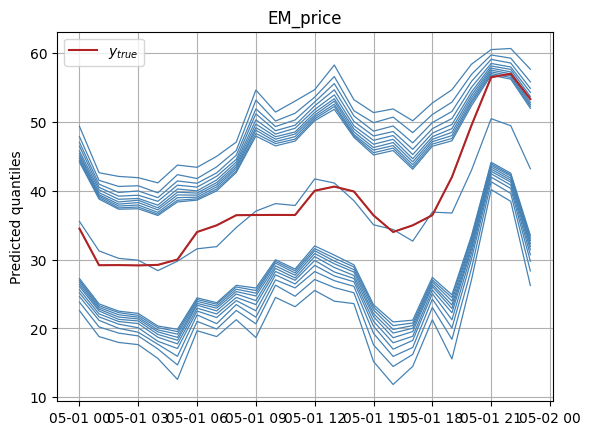

In [ ]:
# Plot test predictions
plot_quantiles(test_predictions, target=PF_task_name)